<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/KNN_OWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("factory_worker_safety_multimodal_dataset_v2.csv")
df.columns

Index(['Report_ID', 'Image_Path', 'Video_Path', 'Audio_Path', 'PPE_Status',
       'Body_Posture', 'Zone_Violation', 'Workers_Visible',
       'PPE_Compliance_Score', 'Image_Confidence', 'Audio_Event',
       'Audio_dB_Level', 'Audio_Dominant_Freq_Hz', 'Audio_Duration_Sec',
       'Audio_Confidence', 'Activity_Detected', 'Motion_Intensity',
       'Fall_Detected', 'Video_Frame_Rate', 'Video_Confidence',
       'Incident_Description', 'Incident_Type', 'Text_Sentiment',
       'Urgency_Level', 'Text_Word_Count', 'Fusion_Risk_Score', 'Risk_Level'],
      dtype='object')

In [4]:
X = df[['PPE_Status', 'Body_Posture', 'Audio_Event','Activity_Detected','Motion_Intensity','PPE_Compliance_Score','Fusion_Risk_Score']]

In [5]:
y = df['Risk_Level']

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le_ppe = LabelEncoder()
le_body = LabelEncoder()
le_audio = LabelEncoder()
le_activity = LabelEncoder()
le_motion = LabelEncoder()
le_target = LabelEncoder()

In [8]:
X['PPE_Status'] = le_ppe.fit_transform(X['PPE_Status'])
X['Body_Posture'] = le_body.fit_transform(X['Body_Posture'])
X['Audio_Event'] = le_audio.fit_transform(X['Audio_Event'])
X['Activity_Detected'] = le_activity.fit_transform(X['Activity_Detected'])
X['Motion_Intensity'] = le_motion.fit_transform(X['Motion_Intensity'])

/tmp/ipykernel_6548/3662847233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['PPE_Status'] = le_ppe.fit_transform(X['PPE_Status'])
/tmp/ipykernel_6548/3662847233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Body_Posture'] = le_body.fit_transform(X['Body_Posture'])
/tmp/ipykernel_6548/3662847233.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [9]:
y = le_target.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)
    print("K =", k, "Score =", score)


K = 1 Score = 0.7233333333333334
K = 2 Score = 0.7233333333333334
K = 3 Score = 0.75
K = 4 Score = 0.7466666666666667
K = 5 Score = 0.7466666666666667
K = 6 Score = 0.76
K = 7 Score = 0.76
K = 8 Score = 0.75
K = 9 Score = 0.7466666666666667
K = 10 Score = 0.7533333333333333
K = 11 Score = 0.7633333333333333
K = 12 Score = 0.77
K = 13 Score = 0.7733333333333333
K = 14 Score = 0.7733333333333333
K = 15 Score = 0.76
K = 16 Score = 0.76
K = 17 Score = 0.76
K = 18 Score = 0.7633333333333333
K = 19 Score = 0.7566666666666667
K = 20 Score = 0.76


In [17]:
best_k = scores.index(max(scores)) + 1
print("Best K Value:", best_k)

Best K Value: 13


In [18]:
model = KNeighborsClassifier(n_neighbors=best_k)

In [19]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7733333333333333


In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[108   0  17   0]
 [  0   8  30   0]
 [ 19   1 116   0]
 [  0   1   0   0]]


In [25]:
import matplotlib.pyplot as plt

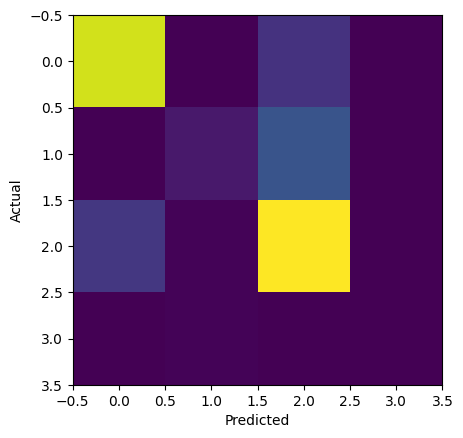

In [26]:
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.metrics import classification_report

In [28]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       125
           1       0.80      0.21      0.33        38
           2       0.71      0.85      0.78       136
           3       0.00      0.00      0.00         1

    accuracy                           0.77       300
   macro avg       0.59      0.48      0.49       300
weighted avg       0.78      0.77      0.75       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    'n_neighbors': range(1, 21)
}

In [31]:
grid = GridSearchCV(KNeighborsClassifier(),param_grid, cv=5)

In [32]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)})

In [33]:
print("Best K:", grid.best_params_)

Best K: {'n_neighbors': 12}


In [34]:
print("Best Score:", grid.best_score_)

Best Score: 0.7658333333333334


In [35]:
import joblib

In [36]:
joblib.dump(model, "knn_model.pkl")

['knn_model.pkl']